# Attn-FiLM UNet: modulation analysis

Probes what `UNet2DAttn`'s cross-attention modulator actually does — descriptive stats, linear probes, causal interventions, OOD organ-embedding sampling, embedding interpolation, task-analogy arithmetic, GANSpace-style PCA, and TCAV-on-FiLM.

All heavy machinery lives in `notebooks/_film_analysis.py`. Each section runs independently after sections 0–3.

## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2
import sys, os
from pathlib import Path
REPO = Path('..').resolve()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import torch
import matplotlib.pyplot as plt
from safetensors.torch import load_file
from torch.utils.data import DataLoader

import notebooks._film_analysis as fa
from nets.unet_attn import UNet2DAttn
from data_classes.datasets import USdatasetOmni
from utils.utils import get_sft_transforms, organ_to_class_dict, class_to_organ_dict
from utils.paths import DATA_DIR

torch.manual_seed(0)
np.random.seed(0)

FIG_DIR = Path('figures/attn'); FIG_DIR.mkdir(parents=True, exist_ok=True)
print('Repo:', REPO)
print('Data:', DATA_DIR, '(exists:', Path(DATA_DIR).exists(), ')')
print('Figures →', FIG_DIR.resolve())

Repo: /media/raid0
Data: /work/phd_ultrasounds/UUSIC_new/datasets/data_all/pt_data (exists: True )
Figures → /media/raid0/US_FiLMUNet/figures/attn


## 1. Model + checkpoint

In [2]:
CHECKPOINT = './loggings/dd9c669e4884/checkpoint-8400/model.safetensors'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

model = UNet2DAttn(
    in_channels=3, num_classes=1, n_organs=10,
    size=16, depth=5,
    attn_start=0, use_attn=True,
    img_size=512, patch_size=8, emb_dim=768, n_heads=8,
    distill=False,
    use_dwt=False, wavelet='haar',
    use_shape=False, shape_res=64,
)

state = load_file(CHECKPOINT)
state = {k: v for k, v in state.items() if 'distill' not in k}
res = model.load_state_dict(state, strict=False)
print('missing:', len(res.missing_keys), 'unexpected:', len(res.unexpected_keys))
model.eval().to(DEVICE)
print('max_channels:', model.size * (2 ** (model.depth + 1)))
print('layer_configs:', model._build_layer_configs())

missing: 0 unexpected: 0
max_channels: 1024
layer_configs: [(0, 16), (1, 32), (2, 32), (3, 64), (4, 64), (5, 128), (6, 128), (7, 256), (8, 256), (9, 512), (10, 512), (11, 1024), (12, 512), (13, 512), (14, 256), (15, 256), (16, 128), (17, 128), (18, 64), (19, 64), (20, 32), (21, 32)]


## 2. Val data

In [3]:
IMG_SIZE = 512
BATCH = 8
assert Path(DATA_DIR).exists(), f'DATA_DIR {DATA_DIR} not found; update utils/paths.py'

test_ds = USdatasetOmni(
    DATA_DIR, split='val_cls',
    transforms=get_sft_transforms(train=False, size=IMG_SIZE),
    data_type='segmentation',
    out_size=IMG_SIZE,
    keep_aspect_ratio=True,
    self_norm=True
)
import random
random.shuffle(test_ds.items)
# test_ds.items = test_ds.items[:100]
loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=4,
                    pin_memory=DEVICE == 'cuda',)
print('test set:', len(test_ds), 'samples')

test set: 1931 samples


In [4]:
nuts_cnt = 0
for item in test_ds.items[:]:
    if item['organ_label'] == 'testicle':
        nuts_cnt+=1
        if nuts_cnt >= 100: test_ds.items.remove(item)
print('test set:', len(test_ds), 'samples')

test set: 1177 samples


## 3. Modulation collection

For each val sample, capture per-layer compact `(γ_max, β_max)` (length = `max_channels`), the organ_id, and the model's per-sample Dice.

In [5]:
# Set MAX_BATCHES=None to use the full test set. Start small while iterating.
# run_forward=False skips the UNet forward pass so this cell completes in seconds.
# Dice scores are computed separately before section 5.2.
MAX_BATCHES = 200
data = fa.collect_modulations(model, loader, DEVICE, max_batches=MAX_BATCHES, run_forward=False)
print('Samples:', len(data['organ_id']), '| layers:', len(data['layers']))
print('Organs present:', sorted(set(int(o) for o in data['organ_id'])))

Samples: 1177 | layers: 22
Organs present: [1, 2, 3, 4, 5, 7]


## 4. Tier 1 — descriptive

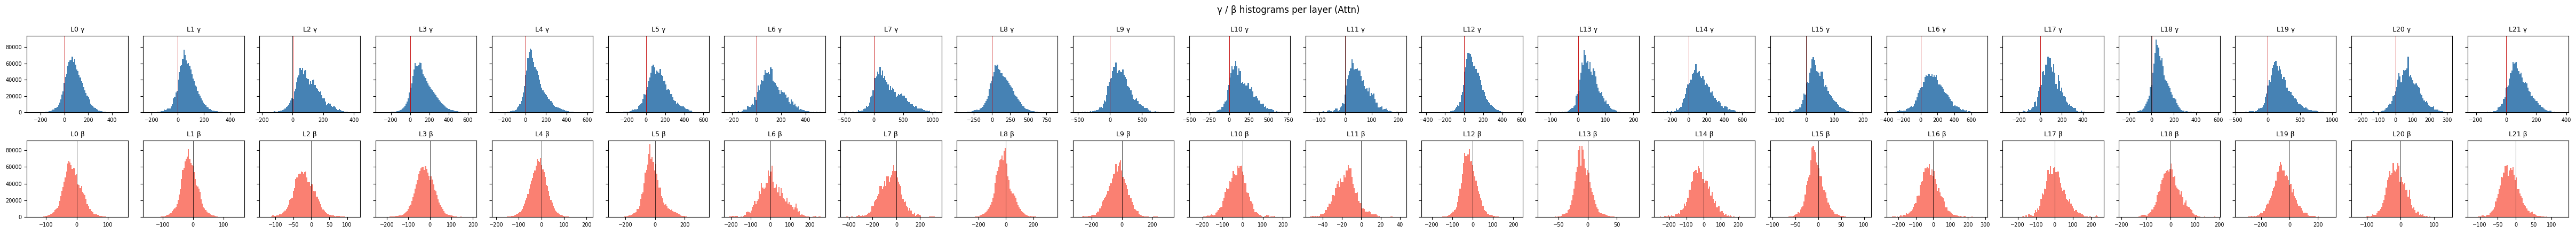

In [6]:
# 4.1 γ / β histograms per layer
layer_ids = sorted(data['layers'].keys())
n = len(layer_ids)
fig, axes = plt.subplots(2, n, figsize=(2.2*n, 4.4), sharey='row')
for i, lid in enumerate(layer_ids):
    g = data['layers'][lid]['gamma'].ravel()
    b = data['layers'][lid]['beta'].ravel()
    axes[0, i].hist(g, bins=80, color='steelblue'); axes[0, i].set_title(f'L{lid} γ', fontsize=9)
    axes[0, i].axvline(0, color='k', lw=.5); axes[0, i].axvline(1, color='r', lw=.5)
    axes[1, i].hist(b, bins=80, color='salmon'); axes[1, i].set_title(f'L{lid} β', fontsize=9)
    axes[1, i].axvline(0, color='k', lw=.5)
    for a in (axes[0,i], axes[1,i]): a.tick_params(labelsize=7)
fig.suptitle('γ / β histograms per layer (Attn)')
fig.tight_layout(); fig.savefig(FIG_DIR/'4_1_hists.png', dpi=130); plt.show()

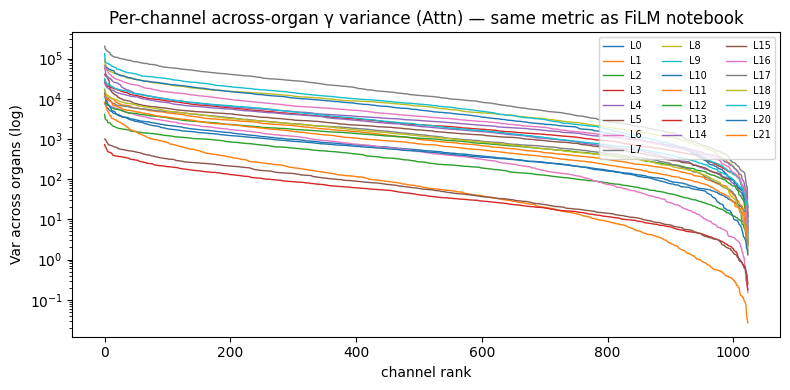

Per-layer variance (median, max, top-10% threshold):
  L 0: median=5.115e+02  max=8.073e+03  top-10% ≥ 2.168e+03
  L 1: median=9.365e+02  max=1.344e+04  top-10% ≥ 4.381e+03
  L 2: median=2.624e+02  max=4.095e+03  top-10% ≥ 1.208e+03
  L 3: median=2.200e+03  max=2.709e+04  top-10% ≥ 8.772e+03
  L 4: median=1.991e+03  max=3.168e+04  top-10% ≥ 7.954e+03
  L 5: median=1.628e+03  max=4.102e+04  top-10% ≥ 5.671e+03
  L 6: median=4.571e+02  max=1.121e+04  top-10% ≥ 2.769e+03
  L 7: median=1.170e+04  max=2.044e+05  top-10% ≥ 6.004e+04
  L 8: median=6.411e+03  max=9.746e+04  top-10% ≥ 2.257e+04
  L 9: median=7.132e+03  max=1.327e+05  top-10% ≥ 3.136e+04
  L10: median=5.053e+03  max=6.741e+04  top-10% ≥ 2.299e+04
  L11: median=6.093e+01  max=8.149e+03  top-10% ≥ 7.868e+02
  L12: median=1.022e+03  max=1.729e+04  top-10% ≥ 3.321e+03
  L13: median=3.906e+01  max=7.290e+02  top-10% ≥ 2.041e+02
  L14: median=2.824e+03  max=5.895e+04  top-10% ≥ 9.565e+03
  L15: median=5.587e+01  max=9.925e+02  top-10%

In [ ]:
# 4.2 Per-channel across-organ γ variance per layer.
# Same formula as the FiLM notebook so the two are directly comparable:
#   var_c = Var_across_organs( mean γ_c | organ )
# We previously normalised by within-organ variance (a proper "selectivity ratio"),
# but the FiLM model has 0 within-organ variance by construction — so we use the
# unnormalised numerator in both notebooks. Higher = channel γ is more organ-discriminative.
var_per_layer = {}
for lid in layer_ids:
    G = data['layers'][lid]['gamma']
    organs = [int(o) for o in np.unique(data['organ_id']) if o >= 0]
    organ_means = np.stack([G[data['organ_id']==o].mean(axis=0) for o in organs])  # (n_organs, C)
    var_per_layer[lid] = organ_means.var(axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
for lid, v in var_per_layer.items():
    ax.plot(np.sort(v)[::-1], label=f'L{lid}', lw=1)
ax.set_yscale('log')
ax.set_xlabel('channel rank'); ax.set_ylabel('Var across organs (log)')
ax.legend(fontsize=7, ncol=3, loc='upper right')
ax.set_title('Per-channel across-organ γ variance (Attn) — same metric as FiLM notebook')
fig.tight_layout(); fig.savefig(FIG_DIR/'4_2_selectivity.png', dpi=130); plt.show()

# Descriptive stats — Attn γ magnitudes are large and channel-heterogeneous, so use
# a relative (top-decile) summary that's scale-free and model-agnostic.
print('Per-layer variance (median, max, top-10% threshold):')
for lid in layer_ids:
    v = var_per_layer[lid]
    print(f'  L{lid:2d}: median={np.median(v):.3e}  max={v.max():.3e}  top-10% ≥ {np.quantile(v, 0.9):.3e}')

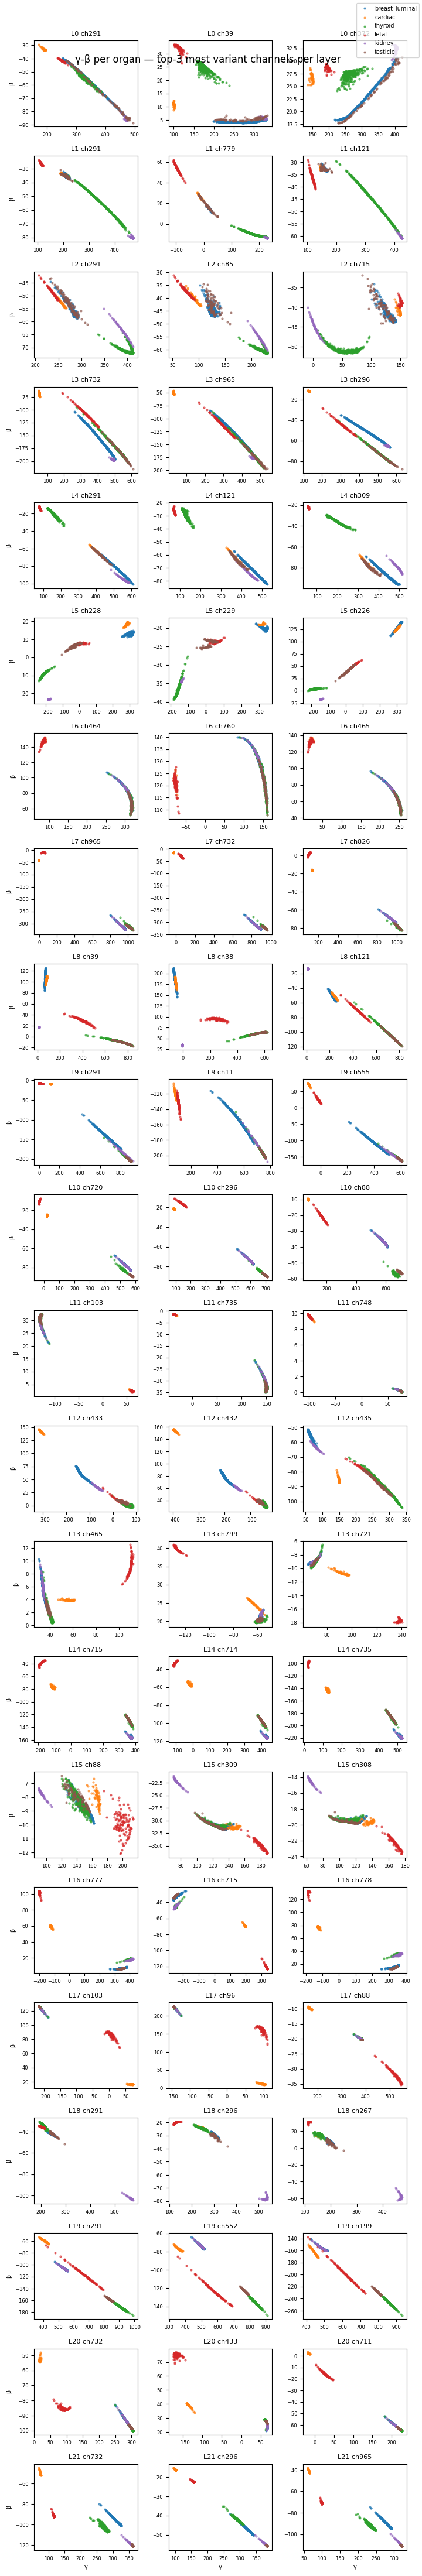

In [ ]:
# 4.3 γ-β scatter per layer for top-3 channels by across-organ variance
organs_seen = sorted([int(o) for o in np.unique(data['organ_id']) if o >= 0])
cmap = plt.cm.tab10
TOP = 3
fig, axes = plt.subplots(len(layer_ids), TOP, figsize=(2.4*TOP, 2.0*len(layer_ids)))
axes = np.atleast_2d(axes)
for r, lid in enumerate(layer_ids):
    top_ch = np.argsort(var_per_layer[lid])[::-1][:TOP]
    G = data['layers'][lid]['gamma']
    B = data['layers'][lid]['beta']
    for c, ch in enumerate(top_ch):
        ax = axes[r, c]
        for oi, o in enumerate(organs_seen):
            m = data['organ_id'] == o
            ax.scatter(G[m, ch], B[m, ch], s=4, color=cmap(oi),
                       label=class_to_organ_dict.get(o, str(o)) if r==0 and c==0 else None, alpha=.6)
        ax.set_title(f'L{lid} ch{ch}', fontsize=8)
        ax.tick_params(labelsize=6)
        if c == 0: ax.set_ylabel('β', fontsize=7)
        if r == len(layer_ids)-1: ax.set_xlabel('γ', fontsize=7)
fig.suptitle('γ-β per organ — top-3 most variant channels per layer')
if axes[0,0].get_legend_handles_labels()[0]:
    fig.legend(*axes[0,0].get_legend_handles_labels(), loc='upper right', fontsize=7)
fig.tight_layout(); fig.savefig(FIG_DIR/'4_3_scatter.png', dpi=130); plt.show()

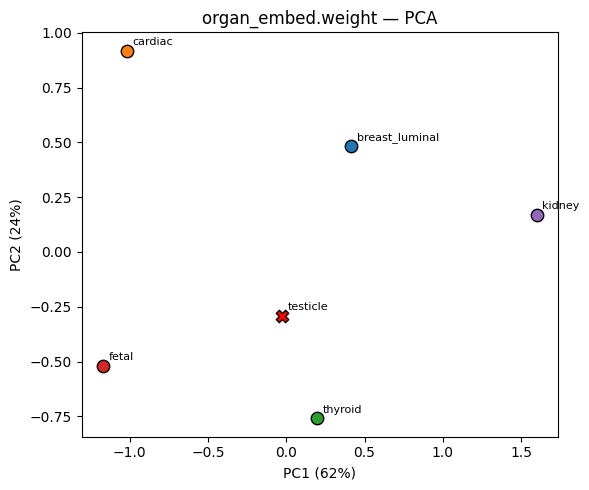

In [ ]:
# 4.4 Organ embedding PCA
from sklearn.decomposition import PCA
emb = model.shared_attn.organ_embed.weight.detach().cpu().numpy()[organs_seen]   # (n_organs+1, D)
pca = PCA(n_components=2).fit(emb)
proj = pca.transform(emb)
fig, ax = plt.subplots(figsize=(6, 5))
for i in range(emb.shape[0]):
    label = class_to_organ_dict.get(organs_seen[i], 'unknown' if i == emb.shape[0]-1 else f'id{i}')
    ax.scatter(proj[i,0], proj[i,1], s=80,
               color='red' if i == emb.shape[0]-1 else cmap(i % 10),
               marker='X' if i == emb.shape[0]-1 else 'o',
               edgecolor='k')
    ax.annotate(label, (proj[i,0], proj[i,1]), fontsize=8, xytext=(4,4), textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
ax.set_title('organ_embed.weight — PCA')
fig.tight_layout(); fig.savefig(FIG_DIR/'4_4_organ_embed_pca.png', dpi=130); plt.show()

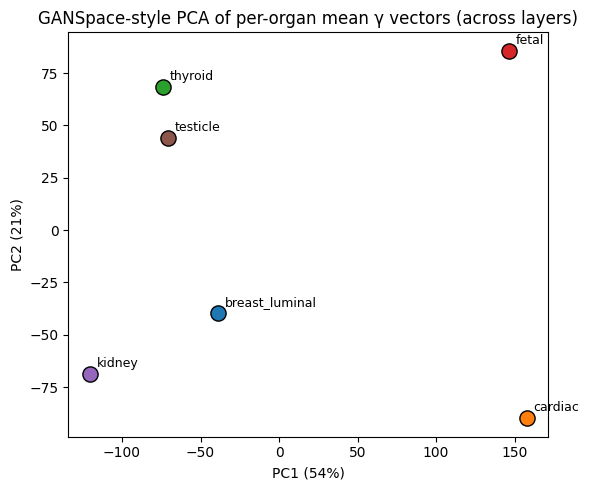

Cumulative explained var: [0.538 0.747 0.891 0.969]


In [ ]:
# 4.5 γ-vector PCA per organ (GANSpace-style: PCA in modulation space, not input embedding space)
proj, pca, organs_used = fa.pca_on_gammas(data['layers'], data['organ_id'], n_components=4)
fig, ax = plt.subplots(figsize=(6, 5))
for i, o in enumerate(organs_used):
    ax.scatter(proj[i, 0], proj[i, 1], s=120, color=cmap(i % 10), edgecolor='k')
    ax.annotate(class_to_organ_dict.get(o, str(o)), (proj[i,0], proj[i,1]),
                fontsize=9, xytext=(5,5), textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%})')
ax.set_title('GANSpace-style PCA of per-organ mean γ vectors (across layers)')
fig.tight_layout(); fig.savefig(FIG_DIR/'4_5_gamma_pca.png', dpi=130); plt.show()
print('Cumulative explained var:', np.cumsum(pca.explained_variance_ratio_).round(3))

## 5. Tier 2 — linear probing

In [7]:
# Compute dice scores — only needed for sections 5.2 and the summary.
# Runs the full UNet forward pass over the dataset (~1–3 min depending on GPU).
data['dice'] = fa.compute_dice_scores(model, loader, DEVICE, max_batches=MAX_BATCHES)

means = []
for i in np.unique(data['organ_id']):
    if i == 7: continue
    means.append((data['dice'][data['organ_id'] == i]).mean())
    print(f"Organ: {i}, # cases: {len((data['dice'][data['organ_id'] == i]))}, mean dice:{means[-1]}")
print(f"Mean Dice (mean of organ means): {np.mean(means):.4f}")

Organ: 1, # cases: 386, mean dice:0.8059639930725098
Organ: 2, # cases: 76, mean dice:0.7974129915237427
Organ: 3, # cases: 428, mean dice:0.5146886706352234
Organ: 4, # cases: 121, mean dice:0.8965529203414917
Organ: 5, # cases: 67, mean dice:0.8931638598442078
Mean Dice (mean of organ means): 0.7816


In [8]:
# 5.1 Linear probe organ_id ← γ at each layer
probe_acc = {}
for lid in layer_ids:
    X = data['layers'][lid]['gamma']
    res = fa.fit_linear_probe(X, data['organ_id'])
    probe_acc[lid] = res
    print(f'L{lid:2d} probe acc: {res["acc"]:.3f} ± {res.get("std",0):.3f}')
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(list(probe_acc.keys()), [v['acc'] for v in probe_acc.values()], 'o-')
ax.set_xlabel('layer id (enc → bottleneck → dec)'); ax.set_ylabel('5-fold accuracy')
ax.axhline(1/len([o for o in np.unique(data['organ_id']) if o>=0]), color='k', ls='--', lw=.5, label='chance')
ax.set_title('Linear probe: organ_id from γ at each layer'); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR/'5_1_probe.png', dpi=130); plt.show()

ValueError: k-fold cross-validation requires at least one train/test split by setting n_splits=2 or more, got n_splits=0.

In [ ]:
# 5.2 Probe Dice ← γ per organ. For Attn: γ has within-organ variance from image conditioning,
# so this should be informative.
valid = data['organ_id'] >= 0
results = []
for o in sorted([int(o) for o in np.unique(data['organ_id'][valid])]):
    m = data['organ_id'] == o
    if m.sum() < 20: continue
    Xs = [data['layers'][lid]['gamma'][m] for lid in layer_ids]
    X = np.concatenate(Xs, axis=1)
    res = fa.fit_dice_regressor(X, data['dice'][m])
    results.append((o, m.sum(), res['r2']))
    print(f'organ {o} ({class_to_organ_dict.get(o,"?")}, n={m.sum()}): R² = {res["r2"]:.3f}')

## 6. Tier 3 — causal interventions

In [9]:
# Precompute per-organ mean γ_max and β_max per layer (compact = max_channels resolution)
g_per_layer_per_organ = []
b_per_layer_per_organ = []
for lid in sorted(data['layers'].keys()):
    g_per, b_per = fa.per_organ_mean_gamma(data['layers'][lid], data['organ_id'])
    g_per_layer_per_organ.append(g_per)
    b_per_layer_per_organ.append(b_per)
layer_configs = model._build_layer_configs()
MAX_C = model.size * (2 ** (model.depth + 1))
INTERVENE_BATCHES = 200  # how many batches to evaluate interventions on

baseline Dice: 0.7816  organ-mean swap Dice: 0.7817  Δ: +0.0001


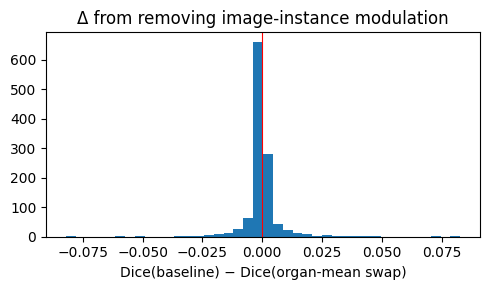

In [18]:
# 6.1 Organ-mean swap: replace per-instance γ/β with organ-mean γ/β
baseline_dices, swapped_dices, organ_ids_6 = [], [], []
for bi, batch in enumerate(loader):
    if bi >= INTERVENE_BATCHES: break
    pv = batch['pixel_values'].to(DEVICE); m = batch['masks'].to(DEVICE)
    oid = batch['organ_id'].to(DEVICE).long()
    with torch.no_grad():
        base = model(pixel_values=pv, organ_id=oid, masks=m)
    baseline_dices.append(fa.compute_per_sample_dice(base['logits'], m).cpu().numpy())
    organ_ids_6.append(oid.cpu().numpy())
    mod_list = fa.build_mod_list_from_per_organ(
        oid.cpu(), g_per_layer_per_organ, b_per_layer_per_organ,
        layer_configs, MAX_C, DEVICE,
        fallback_organ=organs_used[0] if 'organs_used' in dir() else None,
    )
    _, dice_sw = fa.run_with_modulations(model, batch, mod_list, DEVICE)
    swapped_dices.append(dice_sw.cpu().numpy())
baseline = np.concatenate(baseline_dices); swapped = np.concatenate(swapped_dices)
organ_ids_6 = np.concatenate(organ_ids_6)

def _organ_mean(dices, oids):
    return np.mean([dices[oids == o].mean() for o in np.unique(oids) if o >= 0 and o != 7 and (oids == o).sum() > 0])

baseline_m = _organ_mean(baseline, organ_ids_6)
swapped_m  = _organ_mean(swapped, organ_ids_6)
print(f'baseline Dice: {baseline_m:.4f}  organ-mean swap Dice: {swapped_m:.4f}  Δ: {swapped_m-baseline_m:+.4f}')
fig, ax = plt.subplots(figsize=(5,3))
ax.hist(baseline-swapped, bins=40); ax.axvline(0, color='r', lw=.8)
ax.set_xlabel('Dice(baseline) − Dice(organ-mean swap)'); ax.set_title('Δ from removing image-instance modulation')
fig.tight_layout(); fig.savefig(FIG_DIR/'6_1_organ_mean_swap.png', dpi=130); plt.show()

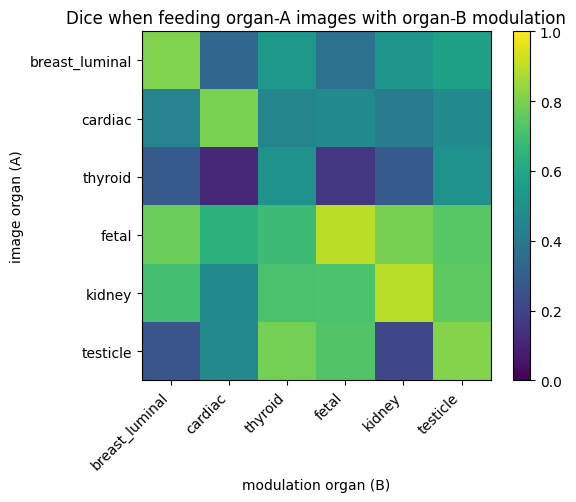

In [ ]:
# 6.2 Cross-organ swap: image of organ A, modulation of organ B's mean
organs_target = organs_used  # from 4.5
K = len(organs_target)
dice_matrix = np.full((K, K), np.nan)
batches_cache = []
for bi, batch in enumerate(loader):
    if bi >= INTERVENE_BATCHES: break
    batches_cache.append(batch)
for ai, organ_a in enumerate(organs_target):
    for bi_, organ_b in enumerate(organs_target):
        dices = []
        for batch in batches_cache:
            oid = batch['organ_id'].long()
            sel = (oid == organ_a)
            if sel.sum() == 0: continue
            sub = {k: v[sel] for k, v in batch.items() if torch.is_tensor(v)}
            B = sub['pixel_values'].shape[0]
            mod_list = fa.build_mod_list_from_per_organ(
                torch.full((B,), organ_b, dtype=torch.long),
                g_per_layer_per_organ, b_per_layer_per_organ,
                layer_configs, MAX_C, DEVICE,
            )
            _, d = fa.run_with_modulations(model, sub, mod_list, DEVICE)
            dices.append(d.cpu().numpy())
        if dices:
            dice_matrix[ai, bi_] = float(np.concatenate(dices).mean())
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(dice_matrix, vmin=0, vmax=1, cmap='viridis')
labels = [class_to_organ_dict.get(o, str(o)) for o in organs_target]
ax.set_xticks(range(K)); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(K)); ax.set_yticklabels(labels)
ax.set_xlabel('modulation organ (B)'); ax.set_ylabel('image organ (A)')
ax.set_title('Dice when feeding organ-A images with organ-B modulation')
fig.colorbar(im, ax=ax); fig.tight_layout(); fig.savefig(FIG_DIR/'6_2_cross_organ.png', dpi=130); plt.show()

In [17]:
oid.item()

1

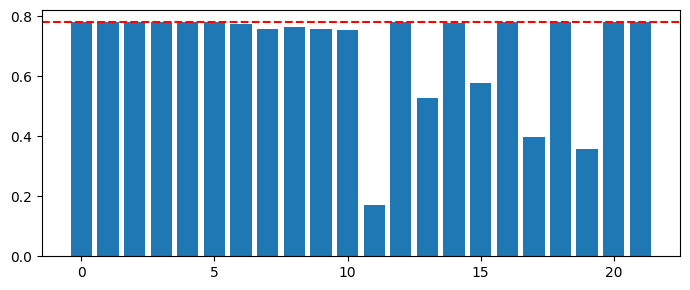

In [19]:
# 6.3 Layer-wise ablation — zero γ←1, β←0 at one layer at a time
layer_ablate_dice = {}
for target_lid in layer_ids:
    dices, oids_abl = [], []
    for bi, batch in enumerate(loader):
        if bi >= INTERVENE_BATCHES: break
        oid = batch['organ_id'].long()
        mod_list = fa.build_mod_list_from_per_organ(
            oid, g_per_layer_per_organ, b_per_layer_per_organ,
            layer_configs, MAX_C, DEVICE,
        )
        # Override target layer with identity
        _, n_ch = layer_configs[target_lid]
        B = batch['pixel_values'].shape[0]
        mod_list[target_lid] = (torch.ones(B, n_ch, 1, 1, device=DEVICE),
                                torch.zeros(B, n_ch, 1, 1, device=DEVICE))
        _, d = fa.run_with_modulations(model, batch, mod_list, DEVICE)
        dices.append(d.cpu().numpy())
        oids_abl.append(oid.numpy())
    if dices:
        layer_ablate_dice[target_lid] = _organ_mean(np.concatenate(dices), np.concatenate(oids_abl))
    else:
        layer_ablate_dice[target_lid] = float('nan')
fig, ax = plt.subplots(figsize=(7,3))
ax.bar(list(layer_ablate_dice.keys()), [v for v in layer_ablate_dice.values()])
ax.axhline(baseline_m, color='r', ls='--', label=f'baseline 0.783')
# ax.set_xlabel('ablated layer'); ax.set_ylabel('Dice'); ax.set_title('Dice after replacing one layer\'s modulation with identity'); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR/'6_3_layer_ablate.png', dpi=130); plt.show()

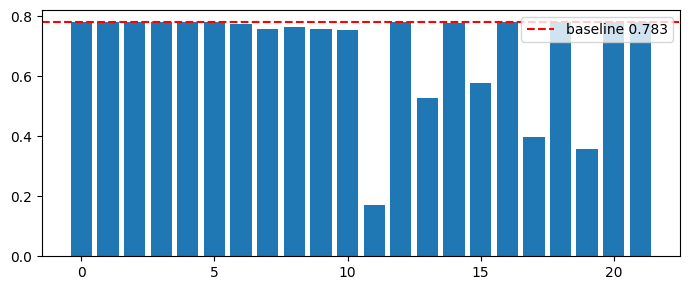

In [ ]:
fig, ax = plt.subplots(figsize=(7,3))
ax.bar(list(layer_ablate_dice.keys()), [v for v in layer_ablate_dice.values()])
ax.axhline(baseline_m, color='r', ls='--', label=f'baseline 0.783')
ax.set_xlabel('ablated layer');
# ax.set_ylabel('Dice'); ax.set_title('Dice after replacing one layer\'s modulation with identity'); 
ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR/'6_3_layer_ablate.png', dpi=130); plt.show()

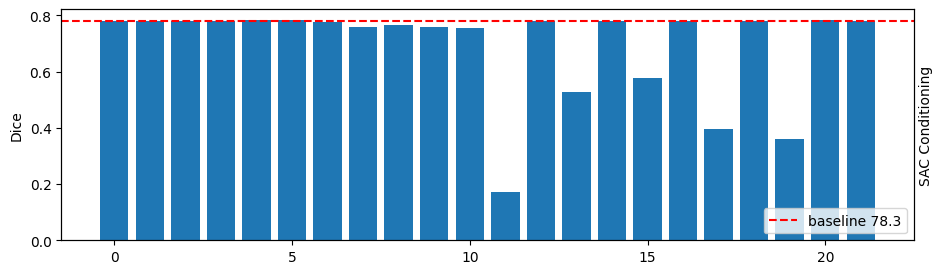

In [29]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11,3))

# 1. Plot your bar chart and baseline on the original left axis
ax.bar(list(layer_ablate_dice.keys()), [v for v in layer_ablate_dice.values()])
ax.axhline(baseline_m, color='r', ls='--', label='baseline 78.3')

ax.set_ylabel('Dice')
# ax.set_title("Dice after replacing one layer's modulation with identity (FiLM)")
ax.legend(loc='upper left') # Forced to left so it doesn't clash with right label

# 2. Create a twin axis on the right
ax_right = ax.twinx()

# 3. Set the label for the right axis
ax_right.set_ylabel('SAC Conditioning')

# 4. Hide the tick marks/labels on the right axis so it stays clean 
# (Otherwise it will show a default 0.0 to 1.0 scale)
ax_right.set_yticks([])
ax.legend(loc='lower right')
# Use bbox_inches='tight' to make sure the new right label isn't cut off
fig.savefig(FIG_DIR/'6_3_layer_ablate_attn.png', dpi=130, bbox_inches='tight')
plt.show()

In [23]:
# 6.4 γ-only vs β-only ablation (across all layers)
def run_partial(zero_gamma: bool, zero_beta: bool):
    out_dices, out_oids = [], []
    for bi, batch in enumerate(loader):
        if bi >= INTERVENE_BATCHES: break
        oid = batch['organ_id'].long()
        mod_list = fa.build_mod_list_from_per_organ(
            oid, g_per_layer_per_organ, b_per_layer_per_organ,
            layer_configs, MAX_C, DEVICE,
        )
        if zero_gamma:
            mod_list = [(torch.ones_like(g), b) for (g, b) in mod_list]
        if zero_beta:
            mod_list = [(g, torch.zeros_like(b)) for (g, b) in mod_list]
        _, d = fa.run_with_modulations(model, batch, mod_list, DEVICE)
        out_dices.append(d.cpu().numpy())
        out_oids.append(oid.numpy())
    return _organ_mean(np.concatenate(out_dices), np.concatenate(out_oids))

full = run_partial(False, False)
gamma_only = run_partial(False, True)   # zero β, keep γ
beta_only = run_partial(True, False)    # zero γ → all 1s, keep β
neither = run_partial(True, True)
print(f'full mod : {full:.4f}\nγ only (β=0): {gamma_only:.4f}\nβ only (γ=1): {beta_only:.4f}\nno mod   : {neither:.4f}')

full mod : 0.7817
γ only (β=0): 0.7542
β only (γ=1): 0.0001
no mod   : 0.5737


## 7. Tier 4 — OOD / embedding sampling

In [12]:
# Sample organ embeddings 4 different ways and feed them through the modulator,
# bypassing the embedding lookup. Run on a single eval batch for a qualitative + quantitative read.
OOD_BATCHES = 200
EMB_DIM = model.shared_attn.organ_embed.weight.shape[1]
organ_W = model.shared_attn.organ_embed.weight.detach().cpu().numpy()  # (n_organs+1, D)
mu_emp, L_emp = fa.empirical_gaussian_params(model.shared_attn.organ_embed.weight)
print('embedding dim:', EMB_DIM, ' organ count incl. unknown:', organ_W.shape[0])

@torch.no_grad()
def eval_with_injected_embedding(emb_fn):
    """emb_fn(B, device) -> (B, D) torch.Tensor."""
    all_dices, all_oids = [], []
    for bi, batch in enumerate(loader):
        if bi >= OOD_BATCHES: break
        pv = batch['pixel_values'].to(DEVICE); m = batch['masks'].to(DEVICE)
        B = pv.shape[0]
        emb = emb_fn(B, DEVICE)
        mod_list = fa.attn_modulations_from_embedding(model, pv, emb, layer_configs)
        with fa.inject_modulations(model, mod_list):
            out = model(pixel_values=pv, organ_id=batch['organ_id'].to(DEVICE).long(), masks=m)
        all_dices.append(fa.compute_per_sample_dice(out['logits'], m).cpu().numpy())
        all_oids.append(batch['organ_id'].numpy())
    if not all_dices:
        return float('nan')
    return _organ_mean(np.concatenate(all_dices), np.concatenate(all_oids))

embedding dim: 768  organ count incl. unknown: 11


In [14]:
# 7.1–7.4 per-organ evaluation
# Iterates the *entire* loader so every organ in test_ds appears. To keep runtime
# bounded on over-represented organs, samples per organ are capped at MAX_PER_ORGAN.
import collections, pandas as pd

MAX_PER_ORGAN = None      # per-strategy cap. Set to None for "use everything".

# 7.1 init prior N(0, 0.02)
def emb_init(B, dev):
    return torch.randn(B, EMB_DIM, device=dev) * 0.02
# 7.2 empirical posterior
def emb_emp(B, dev):
    s = fa.sample_empirical_posterior(mu_emp, L_emp, B)
    return torch.as_tensor(s, dtype=torch.float32, device=dev)
# 7.3 unknown token (the model's built-in OOD slot)
def emb_unk(B, dev):
    return model.shared_attn.organ_embed.weight[-1:].expand(B, -1).to(dev)
# 7.4 nearest-organ proxy — closest trained organ to a random sample
def emb_nearest(B, dev):
    s = fa.sample_empirical_posterior(mu_emp, L_emp, B)
    nearest = fa.nearest_organ_by_cosine(s, organ_W)
    return torch.as_tensor(organ_W[nearest], dtype=torch.float32, device=dev)

strategies = {
    'baseline (true id)':  None,
    '7.1 init N(0,0.02)':  emb_init,
    '7.2 empirical post':  emb_emp,
    '7.3 unknown token':   emb_unk,
    '7.4 nearest organ':   emb_nearest,
}

@torch.inference_mode()
def eval_per_organ(strategies, max_per_organ=None):
    by_strat = {name: collections.defaultdict(list) for name in strategies}
    primary = next(iter(strategies))
    for bi, batch in enumerate(loader):
        oid_np = batch['organ_id'].numpy().astype(int)
        if max_per_organ is None:
            keep = oid_np >= 0
        else:
            keep = np.array([
                o >= 0 and len(by_strat[primary][int(o)]) < max_per_organ
                for o in oid_np
            ])
        if not keep.any():
            continue
        keep_t = torch.as_tensor(keep, dtype=torch.bool)
        pv  = batch['pixel_values'][keep_t].to(DEVICE)
        m   = batch['masks'][keep_t].to(DEVICE)
        oid = batch['organ_id'][keep_t].to(DEVICE).long()
        oid_np_kept = oid.cpu().numpy()
        B = pv.shape[0]
        for name, emb_fn in strategies.items():
            if emb_fn is None:
                out = model(pixel_values=pv, organ_id=oid, masks=m)
            else:
                emb = emb_fn(B, DEVICE)
                mod_list = fa.attn_modulations_from_embedding(model, pv, emb, layer_configs)
                with fa.inject_modulations(model, mod_list):
                    out = model(pixel_values=pv, organ_id=oid, masks=m)
            d = fa.compute_per_sample_dice(out['logits'], m).cpu().numpy()
            for organ_val, dice_val in zip(oid_np_kept, d):
                by_strat[name][int(organ_val)].append(float(dice_val))
        if bi % 25 == 0:
            counts = {int(o): len(by_strat[primary][int(o)]) for o in by_strat[primary]}
            print(f'  batch {bi:4d}: per-organ counts so far = {counts}')
    return by_strat

per_organ = eval_per_organ(strategies, max_per_organ=MAX_PER_ORGAN)

organs_present = sorted({o for v in per_organ.values() for o in v.keys()})
print(f'\nOrgans seen in test_ds: {[(o, class_to_organ_dict.get(o, str(o))) for o in organs_present]}')

mean_by_organ = {name: {o: float(np.mean(per_organ[name][o]))
                        for o in organs_present if per_organ[name].get(o)}
                 for name in strategies}

fig, ax = plt.subplots(figsize=(max(8, len(organs_present) * 1.4), 4.5))
n_strat = len(strategies)
width = 0.8 / n_strat
positions = np.arange(len(organs_present))
for si, name in enumerate(strategies):
    vals = [mean_by_organ[name].get(o, np.nan) for o in organs_present]
    ax.bar(positions + (si - (n_strat - 1) / 2) * width, vals, width, label=name)
ax.set_xticks(positions)
ax.set_xticklabels([class_to_organ_dict.get(o, str(o)) for o in organs_present], rotation=20)
ax.set_ylabel('mean Dice')
ax.set_ylim(0, 1)
ax.set_title(f'Per-organ Dice under OOD embedding strategies (Attn, cap={MAX_PER_ORGAN}/organ)')
ax.legend(fontsize=8, loc='lower right', ncol=2)
ax.grid(axis='y', ls=':', alpha=.4)
fig.tight_layout(); fig.savefig(FIG_DIR/'7_ood_per_organ.png', dpi=130); plt.show()

tbl = pd.DataFrame(
    {name: [mean_by_organ[name].get(o, float('nan')) for o in organs_present]
     for name in strategies},
    index=[class_to_organ_dict.get(o, str(o)) for o in organs_present],
)
n_per_organ = {o: len(per_organ['baseline (true id)'][o]) for o in organs_present}
tbl.insert(0, 'n', [n_per_organ[o] for o in organs_present])
print(tbl.round(3))

results_ood = {name: float(np.mean(list(mean_by_organ[name].values())))
               for name in strategies}

  batch    0: per-organ counts so far = {7: 4, 4: 3, 3: 1}


KeyboardInterrupt: 

## 7.5 Deterministic empirical mean + image-nearest organ

This variant collapses the empirical posterior to the mean trained-organ embedding. For the nearest-organ proxy, each image is treated as unknown: we mean-pool the model's patch embeddings for that image, compare it by cosine distance to per-organ mean image embeddings, then inject the organ-token embedding of the nearest visual prototype.

7.5 image prototypes: {'breast_luminal': 386, 'cardiac': 76, 'thyroid': 428, 'fetal': 121, 'kidney': 67, 'testicle': 99}
  batch    0: per-organ counts so far = {7: 4, 4: 3, 3: 1}
  batch   25: per-organ counts so far = {7: 85, 4: 17, 3: 50, 1: 41, 2: 9, 5: 6}
  batch   50: per-organ counts so far = {7: 99, 4: 39, 3: 121, 1: 106, 2: 26, 5: 17}
  batch   75: per-organ counts so far = {7: 99, 4: 63, 3: 197, 1: 184, 2: 40, 5: 25}
  batch  100: per-organ counts so far = {7: 99, 4: 88, 3: 269, 1: 262, 2: 52, 5: 38}
  batch  125: per-organ counts so far = {7: 99, 4: 107, 3: 354, 1: 323, 2: 64, 5: 61}


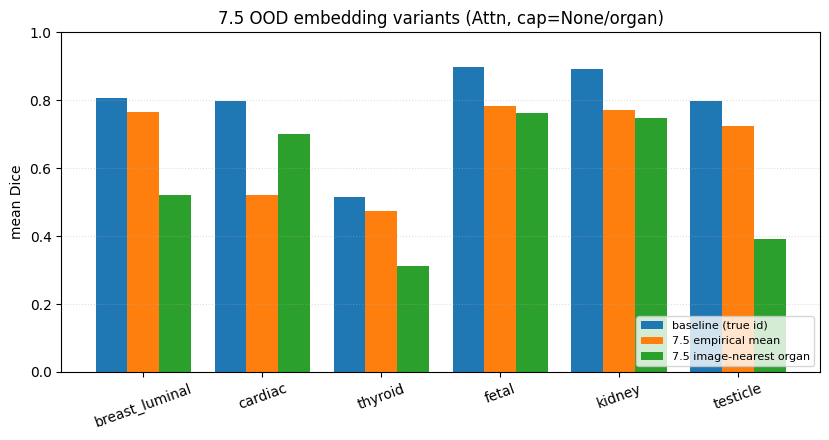

                  n  baseline (true id)  7.5 empirical mean  \
breast_luminal  386               0.806               0.766   
cardiac          76               0.797               0.521   
thyroid         428               0.515               0.473   
fetal           121               0.897               0.783   
kidney           67               0.893               0.771   
testicle         99               0.799               0.724   

                7.5 image-nearest organ  
breast_luminal                    0.522  
cardiac                           0.702  
thyroid                           0.313  
fetal                             0.763  
kidney                            0.747  
testicle                          0.393  

Nearest visual prototype counts:
{'breast_luminal': 279, 'cardiac': 337, 'thyroid': 213, 'fetal': 71, 'kidney': 242, 'testicle': 35}


In [15]:
# 7.5 deterministic empirical posterior + image-prototype nearest organ
import collections, pandas as pd
import torch.nn.functional as F

# Collapse the empirical posterior to the mean of trained organ embeddings.
# The final row in organ_W is the model's unknown token, so exclude it here.
trained_organ_ids = np.arange(organ_W.shape[0] - 1)
organ_W_trained = organ_W[trained_organ_ids]
mu_emp_det = organ_W_trained.mean(axis=0).astype(np.float32)


def emb_empirical_mean_from_batch(pv, dev):
    emb = torch.as_tensor(mu_emp_det, dtype=torch.float32, device=dev)
    return emb.unsqueeze(0).expand(pv.shape[0], -1), None


@torch.inference_mode()
def mean_pooled_image_embedding(pv):
    """Model-side image embedding: mean-pool SharedAttnModulator patch tokens."""
    patches = model.shared_attn.patch_embed(pv)  # (B, N, D)
    return patches.mean(dim=1)                   # (B, D)


@torch.inference_mode()
def build_organ_image_prototypes(max_per_organ=None):
    sums = {}
    counts = collections.defaultdict(int)
    for batch in loader:
        oid_np = batch['organ_id'].numpy().astype(int)
        if max_per_organ is None:
            keep = oid_np >= 0
        else:
            keep = np.array([
                o >= 0 and counts[int(o)] < max_per_organ
                for o in oid_np
            ])
        if not keep.any():
            continue

        pv = batch['pixel_values'][torch.as_tensor(keep, dtype=torch.bool)].to(DEVICE)
        img_emb = F.normalize(mean_pooled_image_embedding(pv), dim=1).detach().cpu()
        for emb, organ_id in zip(img_emb, oid_np[keep]):
            organ_id = int(organ_id)
            if organ_id not in sums:
                sums[organ_id] = torch.zeros_like(emb)
            sums[organ_id] += emb
            counts[organ_id] += 1

    proto_ids = np.array(sorted(sums), dtype=int)
    proto = torch.stack([sums[o] / counts[o] for o in proto_ids], dim=0).to(DEVICE)
    proto = F.normalize(proto, dim=1)
    return proto_ids, proto, dict(counts)


proto_ids_75, proto_img_75, proto_counts_75 = build_organ_image_prototypes(
    max_per_organ=MAX_PER_ORGAN
)
print('7.5 image prototypes:', {
    class_to_organ_dict.get(o, str(o)): proto_counts_75[o]
    for o in proto_ids_75
})


@torch.inference_mode()
def emb_nearest_organ_from_image(pv, dev):
    # Treat the image as unknown: infer the nearest organ from image embeddings only.
    img_emb = F.normalize(mean_pooled_image_embedding(pv), dim=1)
    cosine_distance = 1.0 - (img_emb @ proto_img_75.to(dev).T)
    nearest_pos = cosine_distance.argmin(dim=1).detach().cpu().numpy()
    nearest_ids = proto_ids_75[nearest_pos]
    emb = torch.as_tensor(organ_W[nearest_ids], dtype=torch.float32, device=dev)
    return emb, nearest_ids


strategies_75 = {
    'baseline (true id)': None,
    '7.5 empirical mean': emb_empirical_mean_from_batch,
    '7.5 image-nearest organ': emb_nearest_organ_from_image,
}


@torch.inference_mode()
def eval_per_organ_batch_embeddings(strategies, max_per_organ=None):
    by_strat = {name: collections.defaultdict(list) for name in strategies}
    nearest_by_strat = {name: collections.Counter() for name in strategies}
    primary = next(iter(strategies))

    for bi, batch in enumerate(loader):
        oid_np = batch['organ_id'].numpy().astype(int)
        if max_per_organ is None:
            keep = oid_np >= 0
        else:
            keep = np.array([
                o >= 0 and len(by_strat[primary][int(o)]) < max_per_organ
                for o in oid_np
            ])
        if not keep.any():
            continue

        keep_t = torch.as_tensor(keep, dtype=torch.bool)
        pv = batch['pixel_values'][keep_t].to(DEVICE)
        m = batch['masks'][keep_t].to(DEVICE)
        oid = batch['organ_id'][keep_t].to(DEVICE).long()
        oid_np_kept = oid.cpu().numpy()

        for name, emb_fn in strategies.items():
            if emb_fn is None:
                out = model(pixel_values=pv, organ_id=oid, masks=m)
            else:
                emb, nearest_ids = emb_fn(pv, DEVICE)
                if nearest_ids is not None:
                    nearest_by_strat[name].update(map(int, nearest_ids))
                mod_list = fa.attn_modulations_from_embedding(model, pv, emb, layer_configs)
                with fa.inject_modulations(model, mod_list):
                    out = model(pixel_values=pv, organ_id=oid, masks=m)

            d = fa.compute_per_sample_dice(out['logits'], m).cpu().numpy()
            for organ_val, dice_val in zip(oid_np_kept, d):
                by_strat[name][int(organ_val)].append(float(dice_val))

        if bi % 25 == 0:
            counts = {int(o): len(by_strat[primary][int(o)]) for o in by_strat[primary]}
            print(f'  batch {bi:4d}: per-organ counts so far = {counts}')

    return by_strat, nearest_by_strat


per_organ_75, nearest_counts_75 = eval_per_organ_batch_embeddings(
    strategies_75, max_per_organ=MAX_PER_ORGAN
)

organs_75 = sorted({o for v in per_organ_75.values() for o in v.keys()})
mean_by_organ_75 = {
    name: {o: float(np.mean(per_organ_75[name][o]))
           for o in organs_75 if per_organ_75[name].get(o)}
    for name in strategies_75
}

fig, ax = plt.subplots(figsize=(max(8, len(organs_75) * 1.4), 4.5))
n_strat = len(strategies_75)
width = 0.8 / n_strat
positions = np.arange(len(organs_75))
for si, name in enumerate(strategies_75):
    vals = [mean_by_organ_75[name].get(o, np.nan) for o in organs_75]
    ax.bar(positions + (si - (n_strat - 1) / 2) * width, vals, width, label=name)
ax.set_xticks(positions)
ax.set_xticklabels([class_to_organ_dict.get(o, str(o)) for o in organs_75], rotation=20)
ax.set_ylabel('mean Dice')
ax.set_ylim(0, 1)
ax.set_title(f'7.5 OOD embedding variants (Attn, cap={MAX_PER_ORGAN}/organ)')
ax.legend(fontsize=8, loc='lower right')
ax.grid(axis='y', ls=':', alpha=.4)
fig.tight_layout(); fig.savefig(FIG_DIR/'7_5_ood_per_organ.png', dpi=130); plt.show()

tbl_75 = pd.DataFrame(
    {name: [mean_by_organ_75[name].get(o, float('nan')) for o in organs_75]
     for name in strategies_75},
    index=[class_to_organ_dict.get(o, str(o)) for o in organs_75],
)
n_per_organ_75 = {o: len(per_organ_75['baseline (true id)'][o]) for o in organs_75}
tbl_75.insert(0, 'n', [n_per_organ_75[o] for o in organs_75])
print(tbl_75.round(3))

if nearest_counts_75['7.5 image-nearest organ']:
    print('\nNearest visual prototype counts:')
    print({
        class_to_organ_dict.get(o, str(o)): c
        for o, c in sorted(nearest_counts_75['7.5 image-nearest organ'].items())
    })

results_ood_75 = {name: float(np.mean(list(mean_by_organ_75[name].values())))
                  for name in strategies_75}


## 8. Embedding interpolation

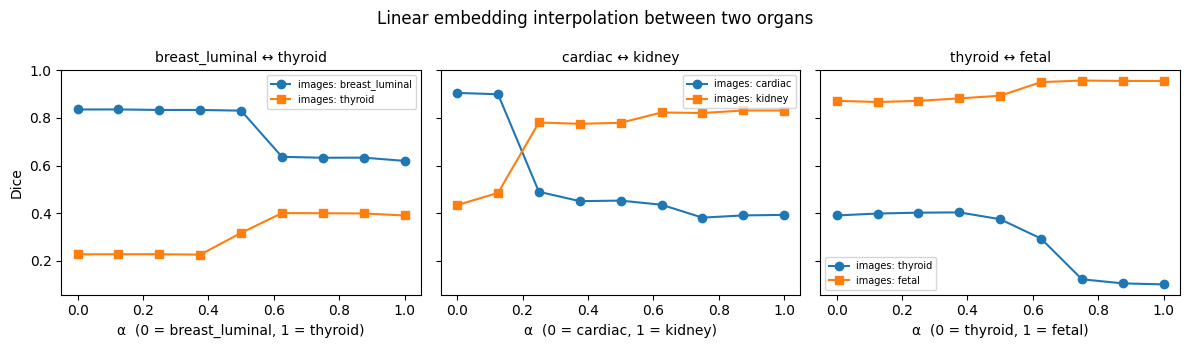

In [ ]:
# For (organ_A, organ_B): traverse e = α·e_B + (1-α)·e_A, evaluate Dice on val images of both.
ALPHAS = np.linspace(0, 1, 9)
PAIRS = [(1, 3), (2, 5), (3, 4)]  # breast↔liver, cardiac↔kidney, thyroid↔fetal — adjust as desired
fig, axes = plt.subplots(1, len(PAIRS), figsize=(4*len(PAIRS), 3.5), sharey=True)
if len(PAIRS) == 1: axes = [axes]
for ax, (a, b) in zip(axes, PAIRS):
    e_a = torch.as_tensor(organ_W[a], device=DEVICE).unsqueeze(0)
    e_b = torch.as_tensor(organ_W[b], device=DEVICE).unsqueeze(0)
    dice_a, dice_b = [], []
    for alpha in ALPHAS:
        emb = (1-alpha) * e_a + alpha * e_b   # (1, D)
        def f_emb(B, dev, _e=emb): return _e.expand(B, -1).to(dev)
        # Evaluate separately on A-organ images and B-organ images
        @torch.inference_mode()
        def eval_for_organ(target_o):
            ds = []
            for bi, batch in enumerate(loader):
                if bi >= 10: break
                sel = batch['organ_id'] == target_o
                if sel.sum() == 0: continue
                sub = {k: v[sel] for k, v in batch.items() if torch.is_tensor(v)}
                pv = sub['pixel_values'].to(DEVICE); m = sub['masks'].to(DEVICE)
                B = pv.shape[0]
                e_sub = f_emb(B, DEVICE)
                mod_list = fa.attn_modulations_from_embedding(model, pv, e_sub, layer_configs)
                with fa.inject_modulations(model, mod_list):
                    out = model(pixel_values=pv, organ_id=sub['organ_id'].to(DEVICE).long(), masks=m)
                ds.append(fa.compute_per_sample_dice(out['logits'], m).cpu().numpy())
            return float(np.concatenate(ds).mean()) if ds else float('nan')
        dice_a.append(eval_for_organ(a))
        dice_b.append(eval_for_organ(b))
    ax.plot(ALPHAS, dice_a, 'o-', label=f'images: {class_to_organ_dict.get(a,a)}')
    ax.plot(ALPHAS, dice_b, 's-', label=f'images: {class_to_organ_dict.get(b,b)}')
    ax.set_xlabel(f'α  (0 = {class_to_organ_dict.get(a,a)}, 1 = {class_to_organ_dict.get(b,b)})')
    ax.set_title(f'{class_to_organ_dict.get(a,a)} ↔ {class_to_organ_dict.get(b,b)}', fontsize=10)
    ax.legend(fontsize=7)
axes[0].set_ylabel('Dice')
fig.suptitle('Linear embedding interpolation between two organs')
fig.tight_layout(); fig.savefig(FIG_DIR/'8_interpolation.png', dpi=130); plt.show()

## 9. Task-analogy arithmetic

In [ ]:
# For each ordered triple (A, B, C), compute e_A - e_B + e_C and find nearest organ embedding.
# Inspired by Perez 2018 'task analogy arithmetic'.
from itertools import permutations
n_organs_trained = organ_W.shape[0] - 1  # last row is 'unknown'
W = organ_W[:n_organs_trained]
results = []
for a, b, c in permutations(range(n_organs_trained), 3):
    v = W[a] - W[b] + W[c]
    sims = (W @ v) / (np.linalg.norm(W, axis=1) * np.linalg.norm(v) + 1e-12)
    nearest = int(sims.argmax())
    results.append((a, b, c, nearest, float(sims.max())))
import pandas as pd
df = pd.DataFrame(results, columns=['A','B','C','nearest','cos_sim'])
df['A_name'] = df['A'].map(class_to_organ_dict)
df['B_name'] = df['B'].map(class_to_organ_dict)
df['C_name'] = df['C'].map(class_to_organ_dict)
df['nearest_name'] = df['nearest'].map(class_to_organ_dict)
# The interesting case is when the nearest organ is not in {A, B, C} — i.e., the arithmetic
# extrapolates to a novel concept rather than collapsing back to a known one.
df['novel'] = df.apply(lambda r: r['nearest'] not in (r['A'], r['B'], r['C']), axis=1)
print('Fraction with novel nearest:', df['novel'].mean().round(3))
df.sort_values('cos_sim', ascending=False).head(15)

Fraction with novel nearest: 0.183


,A,B,C,nearest,cos_sim,A_name,B_name,C_name,nearest_name,novel
99,1,4,5,5,0.951488,breast_luminal,fetal,kidney,kidney,False
393,5,4,1,5,0.951488,kidney,fetal,breast_luminal,kidney,False
468,6,4,5,5,0.944993,liver,fetal,kidney,kidney,False
396,5,4,6,5,0.944993,kidney,fetal,liver,kidney,False
399,5,4,9,5,0.942887,kidney,fetal,NaN,kidney,False
684,9,4,5,5,0.942887,NaN,fetal,kidney,kidney,False
540,7,4,5,5,0.941877,testicle,fetal,kidney,kidney,False
397,5,4,7,5,0.941876,kidney,fetal,testicle,kidney,False
27,0,4,5,5,0.941238,appendix,fetal,kidney,kidney,False
392,5,4,0,5,0.941238,kidney,fetal,appendix,kidney,False


## 10. TCAV-on-FiLM

Treat per-image γ vector at a layer as the 'activation'. Train a linear SVM: organ-k vs rest → CAV. Estimate the directional derivative of Dice along CAV with a finite difference.

In [ ]:
from sklearn.preprocessing import StandardScaler
TCAV_BATCHES = 10  # small — TCAV is expensive (one extra forward per sample per layer per organ)
EPS = 0.05
organs_for_tcav = [o for o in organs_used if (data['organ_id']==o).sum() >= 30]
tcav_scores = np.full((len(organs_for_tcav), len(layer_ids)), np.nan)
for oi, o in enumerate(organs_for_tcav):
    y = (data['organ_id'] == o).astype(int)
    for li_idx, lid in enumerate(layer_ids):
        X = data['layers'][lid]['gamma']
        try:
            cav_raw = fa.compute_cav(X, y)  # (C,)
        except Exception as e:
            continue
        # Estimate dDice/dγ_along_CAV via finite difference:
        # we perturb γ_max at layer lid by ±EPS·cav and re-run forward.
        # use a small set of organ-o images.
        positives = []
        seen = 0
        for bi, batch in enumerate(loader):
            if seen >= TCAV_BATCHES * BATCH: break
            sel = batch['organ_id'] == o
            if sel.sum() == 0: continue
            sub = {k: v[sel] for k, v in batch.items() if torch.is_tensor(v)}
            B = sub['pixel_values'].shape[0]
            seen += B
            # Baseline mod_list = organ_o mean
            mod_list_base = fa.build_mod_list_from_per_organ(
                torch.full((B,), o, dtype=torch.long),
                g_per_layer_per_organ, b_per_layer_per_organ,
                layer_configs, MAX_C, DEVICE,
            )
            cav_t = torch.as_tensor(cav_raw, dtype=torch.float32, device=DEVICE).view(1, -1, 1, 1)
            # Add perturbation only at the target layer (adaptively pool from MAX_C → n_ch)
            target_lid, n_ch = layer_configs[li_idx]
            pert = torch.nn.functional.adaptive_avg_pool1d(cav_t.view(1, -1), n_ch).view(1, n_ch, 1, 1)
            mod_plus = [m for m in mod_list_base]
            mod_plus[li_idx] = (mod_list_base[li_idx][0] + EPS * pert, mod_list_base[li_idx][1])
            mod_minus = [m for m in mod_list_base]
            mod_minus[li_idx] = (mod_list_base[li_idx][0] - EPS * pert, mod_list_base[li_idx][1])
            _, d_plus = fa.run_with_modulations(model, sub, mod_plus, DEVICE)
            _, d_minus = fa.run_with_modulations(model, sub, mod_minus, DEVICE)
            dd = (d_plus - d_minus).cpu().numpy() / (2 * EPS)
            positives.append((dd > 0).astype(int))
        if positives:
            tcav_scores[oi, li_idx] = float(np.concatenate(positives).mean())
    print(f'organ {o} done')
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(tcav_scores, vmin=0, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(layer_ids))); ax.set_xticklabels(layer_ids)
ax.set_yticks(range(len(organs_for_tcav))); ax.set_yticklabels([class_to_organ_dict.get(o, str(o)) for o in organs_for_tcav])
ax.set_xlabel('layer'); ax.set_ylabel('organ concept')
ax.set_title('TCAV: fraction of samples with +∂Dice/∂γ along CAV (0.5 = no signal)')
fig.colorbar(im, ax=ax); fig.tight_layout(); fig.savefig(FIG_DIR/'10_tcav.png', dpi=130); plt.show()

## 11. Summary

In [ ]:
_organ_ids_valid = [i for i in np.unique(data['organ_id']) if i >= 0]
_mean_dice = np.mean([data['dice'][data['organ_id'] == i].mean() for i in _organ_ids_valid])
print('=== Summary (Attn UNet) ===')
print(f'Samples analysed       : {len(data["organ_id"])}')
print(f'Mean baseline Dice     : {_mean_dice:.4f}  (mean of organ means)')
print('Per-layer probe accuracy (5-fold):')
for lid in layer_ids:
    print(f'  L{lid:2d}: {probe_acc[lid]["acc"]:.3f}')
print('Per-layer cross-organ γ variance (median):')
for lid in layer_ids:
    print(f'  L{lid:2d}: median={np.median(var_per_layer[lid]):.3e}')
print('OOD strategies mean Dice:')
for k, v in results_ood.items():
    print(f'  {k}: {v:.4f}')
print(f'\nFigures saved to {FIG_DIR.resolve()}')

## 12. Learn a custom organ embedding

Everything is frozen except a single trainable `(1, emb_dim)` vector that we feed as the organ query into the cross-attention modulator. The vector is trained to minimise `DiceBCELoss` (the same loss the model was trained with) over the augmented `val_cls` split. This finds the embedding the model is most "happy" with for organ-agnostic segmentation — effectively a learned version of the built-in unknown token.

In [ ]:
out['loss']

In [8]:
import torch.nn.functional as F
from nets.segm_net import DiceBCELoss
from tqdm import tqdm
# 1. Freeze the entire model; keep eval mode so dropout / norm are deterministic.
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

# 2. Trainable embedding — initialised at the empirical-organ mean so we start
#    inside the model's learned manifold rather than far away at the origin.
custom_emb = torch.nn.Parameter(
    torch.as_tensor(mu_emp, dtype=torch.float32, device=DEVICE).unsqueeze(0)
)
optimizer = torch.optim.Adam([custom_emb], lr=1e-5)

# 3. Training dataset with augmentations (different from the val loader above).
train_ds_custom = USdatasetOmni(
    DATA_DIR, split='train_cls',
    transforms=get_sft_transforms(train=True, size=IMG_SIZE),
    data_type='segmentation',
    out_size=IMG_SIZE,
    keep_aspect_ratio=True,
    self_norm=True,
)
train_loader_custom = DataLoader(
    train_ds_custom, batch_size=8, shuffle=True, num_workers=8,
    pin_memory=DEVICE == 'cuda', prefetch_factor=10
)
print(f'Training samples: {len(train_ds_custom)}')

# 4. Re-implementation of attn_modulations_from_embedding WITHOUT @torch.no_grad
#    so gradients can flow from the loss back to `custom_emb`.
def compute_mods_with_grad(emb, pv):
    sa = model.shared_attn
    B = emb.shape[0]
    patches = sa.patch_embed(pv)                            # (B, N, D)
    mod_list = []
    for layer_id, n_channels in layer_configs:
        layer_emb_vec = sa.layer_embed(torch.tensor([layer_id], device=DEVICE)).expand(B, -1)
        q = emb + layer_emb_vec                             # (B, D)
        queries_organ = q.unsqueeze(1)
        influence = sa.influence_token.expand(B, -1, -1)
        queries = torch.cat([influence, queries_organ], dim=1)
        attn_out, _ = sa.attn(query=queries, key=patches, value=patches)
        attn_out = attn_out.mean(dim=1)
        x = sa.shared_norm(attn_out)
        x = sa.layer_linears[layer_id](x)
        x = sa.shared_gelu(x)
        x = sa.shared_dropout(x)
        gb = sa.shared_output(x)
        beta_max, gamma_max = gb.chunk(2, dim=-1)
        beta  = F.adaptive_avg_pool1d(beta_max,  n_channels).unsqueeze(-1).unsqueeze(-1)
        gamma = F.adaptive_avg_pool1d(gamma_max, n_channels).unsqueeze(-1).unsqueeze(-1)
        mod_list.append((gamma, beta))
    return mod_list

# 5. Training loop
N_EPOCHS = 3
LOG_EVERY = 20
losses = []
for ep in range(N_EPOCHS):
    epoch_losses = []
    for bi, batch in tqdm(enumerate(train_loader_custom)):
        pv  = batch['pixel_values'].to(DEVICE)
        m   = batch['masks'].to(DEVICE)
        oid = batch['organ_id'].to(DEVICE).long()
        B   = pv.shape[0]

        emb_b    = custom_emb.expand(B, -1)
        mod_list = compute_mods_with_grad(emb_b, pv)
        with fa.inject_modulations(model, mod_list):
            out = model(pixel_values=pv, organ_id=oid, masks=m)
        loss = out['loss']

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        epoch_losses.append(loss.item())
        if bi % LOG_EVERY == 0:
            print(f'  epoch {ep} batch {bi:4d}  loss={loss.item():.4f}')
    print(f'epoch {ep} mean loss: {np.mean(epoch_losses):.4f}')

# 6. Loss curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, lw=1)
ax.set_xlabel('iteration'); ax.set_ylabel('DiceBCE loss')
ax.set_title('Training a custom organ embedding (Attn UNet, model frozen)')
ax.grid(ls=':', alpha=.5)
fig.tight_layout(); fig.savefig(FIG_DIR/'custom_emb_loss.png', dpi=130); plt.show()

# 7. Where did the learned embedding land relative to the trained organs?
final_emb = custom_emb.detach().cpu().numpy().squeeze()
print(f'\nFinal custom embedding shape: {final_emb.shape}')
print('L2 distance from each trained organ:')
for i in range(organ_W.shape[0]):
    d = float(np.linalg.norm(final_emb - organ_W[i]))
    name = class_to_organ_dict.get(i, 'unknown' if i == organ_W.shape[0]-1 else f'id{i}')
    print(f'  {name:15s}: {d:.4f}')

# 8. Per-organ evaluation of the learned embedding, side-by-side with section-7 baselines.
def emb_custom(B_, dev):
    return custom_emb.detach().expand(B_, -1).to(dev)

strategies_eval = {**strategies, 'custom (learned)': emb_custom}
per_organ_eval  = eval_per_organ(strategies_eval, max_per_organ=MAX_PER_ORGAN)
organs_eval     = sorted({o for v in per_organ_eval.values() for o in v.keys()})
mean_eval = {name: {o: float(np.mean(per_organ_eval[name][o]))
                    for o in organs_eval if per_organ_eval[name].get(o)}
             for name in strategies_eval}

fig, ax = plt.subplots(figsize=(max(8, len(organs_eval) * 1.5), 4.5))
n_strat = len(strategies_eval)
width = 0.8 / n_strat
positions = np.arange(len(organs_eval))
for si, name in enumerate(strategies_eval):
    vals = [mean_eval[name].get(o, np.nan) for o in organs_eval]
    ax.bar(positions + (si - (n_strat - 1) / 2) * width, vals, width, label=name)
ax.set_xticks(positions)
ax.set_xticklabels([class_to_organ_dict.get(o, str(o)) for o in organs_eval], rotation=20)
ax.set_ylabel('mean Dice'); ax.set_ylim(0, 1)
ax.set_title('Per-organ Dice — baselines + learned custom embedding')
ax.legend(fontsize=8, loc='lower right', ncol=2)
ax.grid(axis='y', ls=':', alpha=.4)
fig.tight_layout(); fig.savefig(FIG_DIR/'custom_emb_per_organ.png', dpi=130); plt.show()

In [10]:
strategies_eval = {**strategies, 'custom (learned)': emb_custom}
per_organ_eval  = eval_per_organ(strategies_eval, max_per_organ=MAX_PER_ORGAN)
organs_eval     = sorted({o for v in per_organ_eval.values() for o in v.keys()})
mean_eval = {name: {o: float(np.mean(per_organ_eval[name][o]))
                    for o in organs_eval if per_organ_eval[name].get(o)}
             for name in strategies_eval}

fig, ax = plt.subplots(figsize=(max(8, len(organs_eval) * 1.5), 4.5))
n_strat = len(strategies_eval)
width = 0.8 / n_strat
positions = np.arange(len(organs_eval))
for si, name in enumerate(strategies_eval):
    vals = [mean_eval[name].get(o, np.nan) for o in organs_eval]
    ax.bar(positions + (si - (n_strat - 1) / 2) * width, vals, width, label=name)
ax.set_xticks(positions)
ax.set_xticklabels([class_to_organ_dict.get(o, str(o)) for o in organs_eval], rotation=20)
ax.set_ylabel('mean Dice'); ax.set_ylim(0, 1)
ax.set_title('Per-organ Dice — baselines + learned custom embedding')
ax.legend(fontsize=8, loc='lower right', ncol=2)
ax.grid(axis='y', ls=':', alpha=.4)
fig.tight_layout(); fig.savefig(FIG_DIR/'custom_emb_per_organ.png', dpi=130); plt.show()